# Clustering Analysis


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#run before importing KMeans

import os
os.environ["OMP_NUM_THREADS"] = '1'

In [2]:
# Load the Excel file
dataset = pd.read_excel("sku_data .xlsx")

In [ ]:
# The xlsx file is then converted  and saved CSV file (cause csv is goat)
dataset.to_csv("sku_data.csv", index=False)

In [4]:
#Pandas is used to prints a structured summary of the DataFrame to get an overview of the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2279 entries, 0 to 2278
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2279 non-null   int64  
 1   Unitprice        2279 non-null   float64
 2   Expire date      2279 non-null   int64  
 3   Outbound number  2279 non-null   int64  
 4   Total outbound   2279 non-null   float64
 5   Pal grossweight  2279 non-null   float64
 6   Pal height       2279 non-null   float64
 7   Units per pal    2279 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 142.6 KB


In [ ]:

dataset.describe()

,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
count,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000
mean,1140.000000,4.269402,410.371654,235.976305,731.701053,192.939582,0.672798,755.563405
std,658.034953,14.449000,240.875419,700.230685,2146.029848,164.616813,0.552117,6278.437915
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,570.500000,0.000000,365.000000,0.000000,0.000000,60.000000,0.000000,32.000000
50%,1140.000000,1.293800,547.000000,1.000000,3.000000,167.680000,0.840000,108.000000
75%,1709.500000,4.545000,547.000000,45.000000,419.500000,277.560000,1.020000,384.000000
max,2279.000000,518.592000,734.000000,6325.000000,26411.000000,907.200000,2.160000,200000.000000


In [ ]:
dataset.head()

,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,1,0.058,547,9,2441.0,105.60,1.56,1920
1,2,0.954,547,0,0.0,207.68,1.00,384
2,3,2.385,547,12,23.0,165.78,1.02,108
3,4,5.100,547,0,0.0,221.04,1.05,72
4,5,0.000,547,0,0.0,0.00,0.00,0


In [7]:
#Checking how many missing values are in each column of your DataFrame.

dataset.isnull().sum()

ID                 0
Unitprice          0
Expire date        0
Outbound number    0
Total outbound     0
Pal grossweight    0
Pal height         0
Units per pal      0
dtype: int64

In [8]:
# Inpecting the dataset shows that many rows have Unitprice = 0, therefore checking the number of rows with Unitprice=0
(dataset["Unitprice"] == 0).sum()

np.int64(710)

# Data Preprocessing and Preparation


In [9]:
# Removing rows where Unitprice equals zero
dataset_cleaned = dataset[dataset["Unitprice"] != 0]

In [10]:
# Display first five rows to show what the (cleaned) dataset looks like after removing rows where Unitprice = 0
dataset_cleaned.head()

,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,1,0.058,547,9,2441.0,105.60,1.56,1920
1,2,0.954,547,0,0.0,207.68,1.00,384
2,3,2.385,547,12,23.0,165.78,1.02,108
3,4,5.100,547,0,0.0,221.04,1.05,72
5,6,1.110,547,1,1.0,207.68,1.00,384


In [11]:
# Dropping the ID column since it's not useful for clustering, this now gives us the "final dataset"
dataset_final = dataset_cleaned.drop(columns=["ID"])

In [12]:
# Now display the first five rows to check the final dataset after dropping ID
dataset_final.head()

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,0.058,547,9,2441.0,105.60,1.56,1920
1,0.954,547,0,0.0,207.68,1.00,384
2,2.385,547,12,23.0,165.78,1.02,108
3,5.100,547,0,0.0,221.04,1.05,72
5,1.110,547,1,1.0,207.68,1.00,384


In [13]:
# Log-transforming skewed features to reduce skewness
dataset_final['Outbound number']   = np.log1p(dataset_final['Outbound number'])
dataset_final['Total outbound']    = np.log1p(dataset_final['Total outbound'])
dataset_final['Unitprice']         = np.log1p(dataset_final['Unitprice'])
dataset_final['Pal grossweight']   = np.log1p(dataset_final['Pal grossweight'])
dataset_final['Units per pal']     = np.log1p(dataset_final['Units per pal'])


In [14]:
# Replacing 0s in physical attributes (which may be invalid) with median values
for col in ['Pal grossweight', 'Pal height', 'Units per pal']:
    dataset_final[col] = dataset_final[col].replace(0, np.nan)
    dataset_final[col] = dataset_final[col].fillna(dataset_final[col].median())

In [15]:
#Showing a summary of the  final (cleaned) dataset
dataset_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1569 entries, 0 to 2244
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unitprice        1569 non-null   float64
 1   Expire date      1569 non-null   int64  
 2   Outbound number  1569 non-null   float64
 3   Total outbound   1569 non-null   float64
 4   Pal grossweight  1569 non-null   float64
 5   Pal height       1569 non-null   float64
 6   Units per pal    1569 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 98.1 KB


In [16]:
dataset_final.describe()

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
count,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000
mean,1.464610,479.826641,2.736386,3.566231,5.381607,1.049220,5.059153
std,0.923839,187.965441,2.771688,3.269913,0.585726,0.263411,1.358304
min,0.003295,0.000000,0.000000,0.000000,0.693147,0.040000,1.098612
25%,0.722706,456.000000,0.000000,0.000000,5.116676,1.000000,4.290459
50%,1.335001,547.000000,1.609438,2.708050,5.428468,1.020000,4.691348
75%,2.021018,547.000000,5.347108,6.803505,5.686161,1.050000,5.953243
max,6.253044,734.000000,8.752423,10.181574,6.811465,2.160000,12.206078


Seaborn is then used to exploring some numerical variables using "pairplot()".

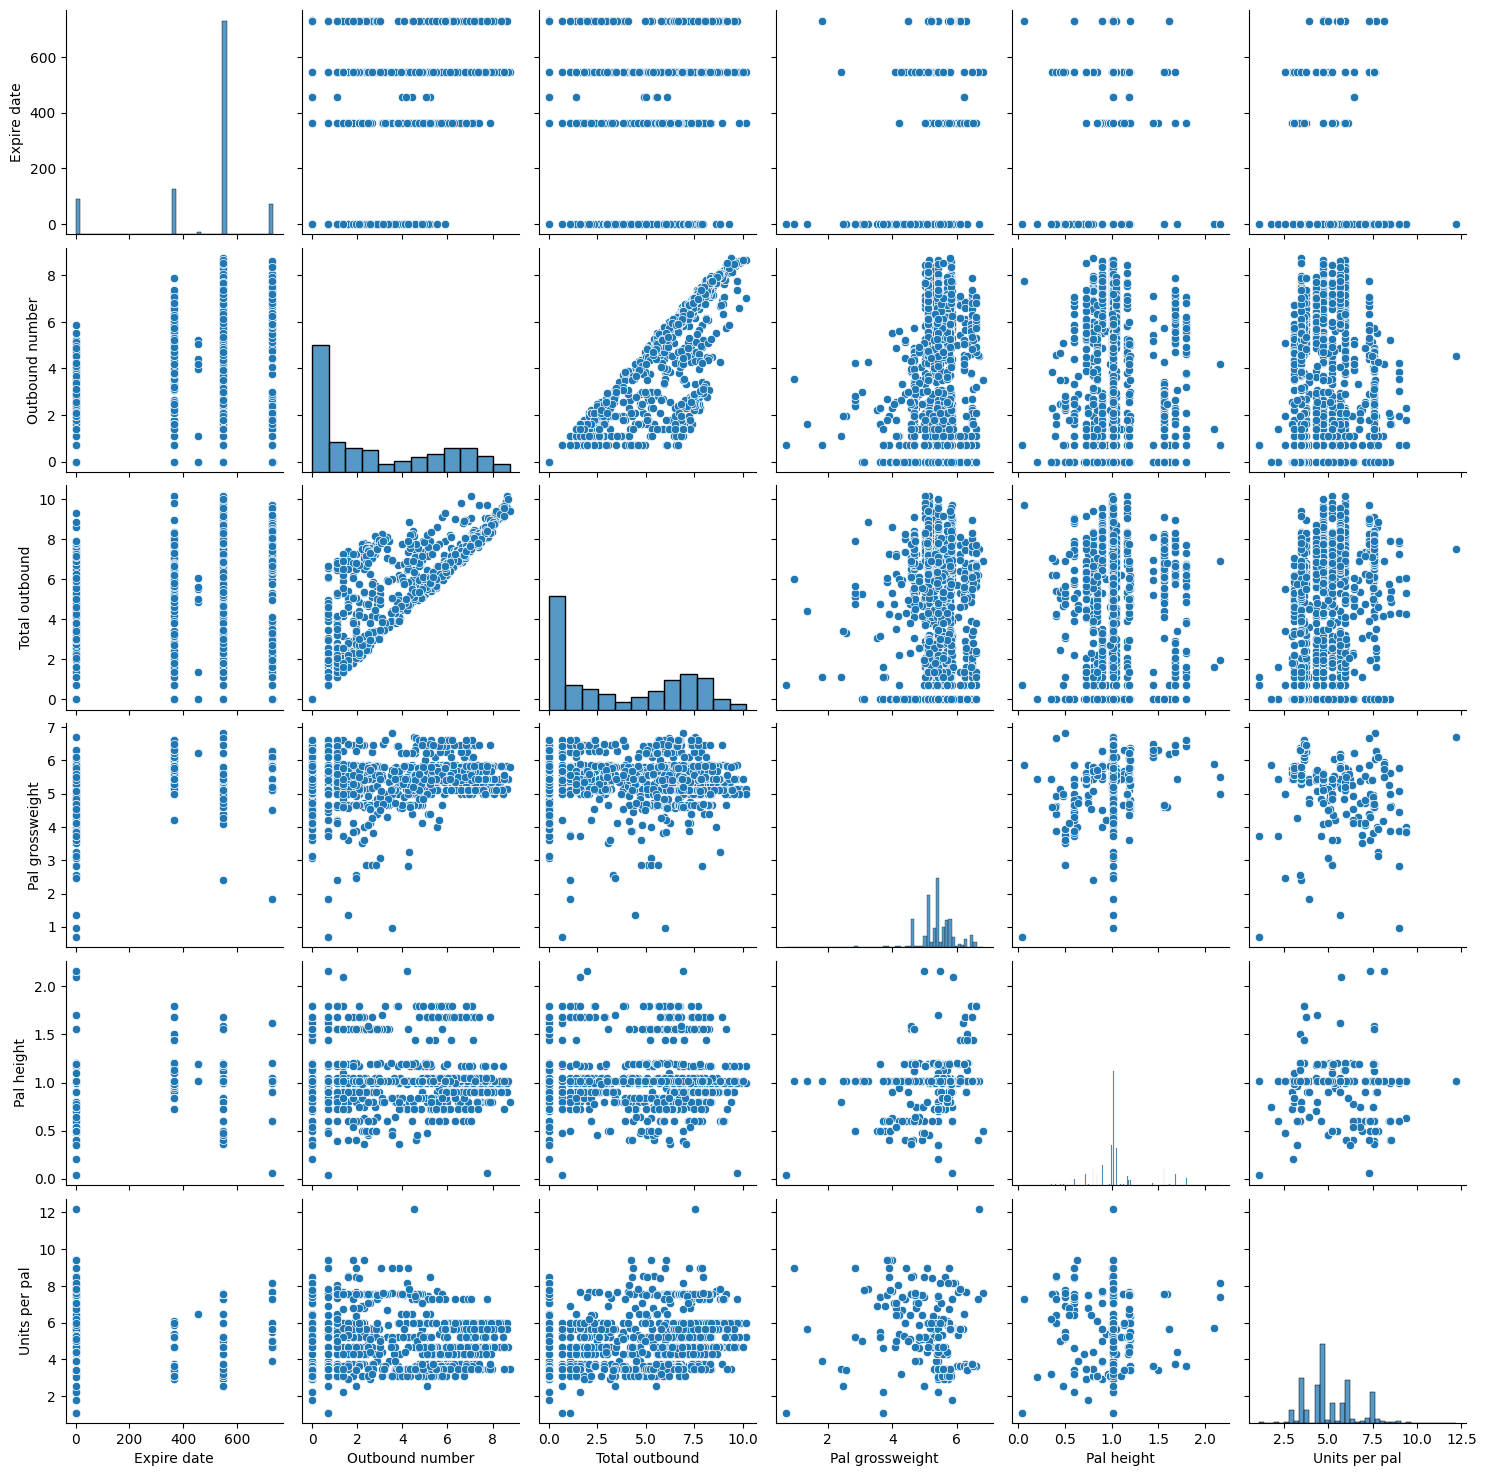

In [17]:
# scatterplots for Outbound number, Total Outbound and Pal grossweight and a histogram for each variable too is shown below.

X = dataset_final.iloc[:,1:8]
sns.pairplot(X)

# Clustering Algorithm Implementation


In [18]:
#Scaling the data

from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X = sc_X.fit_transform(X)

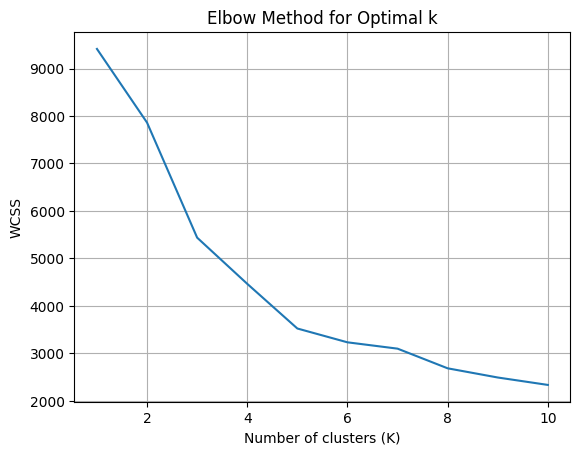

In [19]:
#Using Elbow method: compute inertia (wcss) for k = 1 to 10 to find the optimal number of clusters

from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure()
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# K-Means Clustering Implementation


Looking at the curve above, notice how:

There is a big drop from k = 1 to 3

After k = 3, the curve starts to flatten, meaning each additional cluster provides only a small improvement.

This “bend” or elbow around k = 3 indicates that adding more clusters does not significantly reduce WCSS.

In [20]:
#After identifying the optimal number of clusters (3 above), the "fit_predict method" is used to train the "k-means() method" on the dataset and return  an array y_Kmeans.

# It tells us which cluster each row has been assigned.

#Fitting K-Means to the dataset
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [21]:
#Reducing the dimentionality before we can visualise

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

pca.explained_variance_ratio_

array([0.33433724, 0.25388046])

In [22]:
#Identifying how much of the original variance the two new dimensions explain by returning the explained_variance_ratio attribute and summing the values.

sum(pca.explained_variance_ratio_)

np.float64(0.5882176969250004)

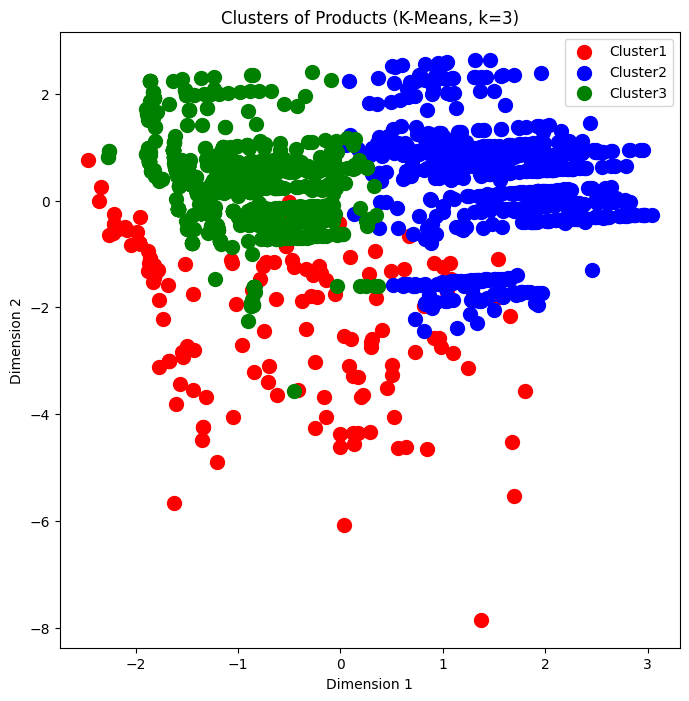

In [23]:
#Lets now plot the scatterplot using the code similar to that used above.


#Visualising the clusters

colours = ['red', 'blue', 'green']

plt.figure(figsize =(8,8))
for i in range(3):
    plt.scatter(X_reduced[y_kmeans == i, 0], X_reduced[y_kmeans == i, 1],
                s =100, c = colours[i], label = 'Cluster' +str(i+1))
plt.title('Clusters of Products (K-Means, k=3)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()  

# Hierarchical Clustering Implementation


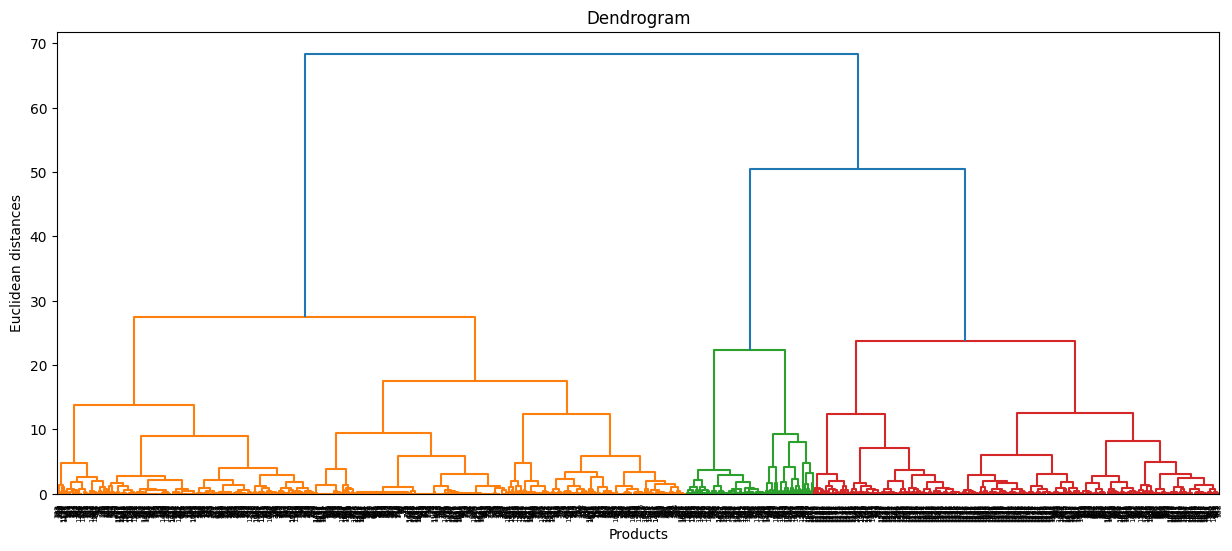

In [24]:
#Using the dendrogram to find the optimal number of clusters

#If you draw a horizontal line across the dendrogram, the number of vertical lines crossing 
#the line equates to the number of clusters.

#Typically we take a horizontal line around halfway down the dendrogram to identify the optimal
#number of clusters, which in this case gives us 4 as seen in the dendrogram below.

import scipy.cluster.hierarchy as sch

plt.figure(figsize =(15, 6))
dendrogram = sch.dendrogram(sch.linkage(X_reduced, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Products')
plt.ylabel('Euclidean distances')
plt.show()

The key observation:

-From the dendrogram above; 
There is one very large jump in distance at the top of the dendrogram:
The blue cluster merges at a very high height (~68–70)
The next merges happen much lower (~50), and others around 20–30
-If you draw a horizontal cut around distance = 50, it would intersect 3 main branches:
Left cluster (orange), Middle small cluster (green), Right cluster (red)
-Therefore, the optimal number of clusters is 3.

In [25]:
#Fitting Heirarchical clustering to the dataset
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters =3, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X_reduced)

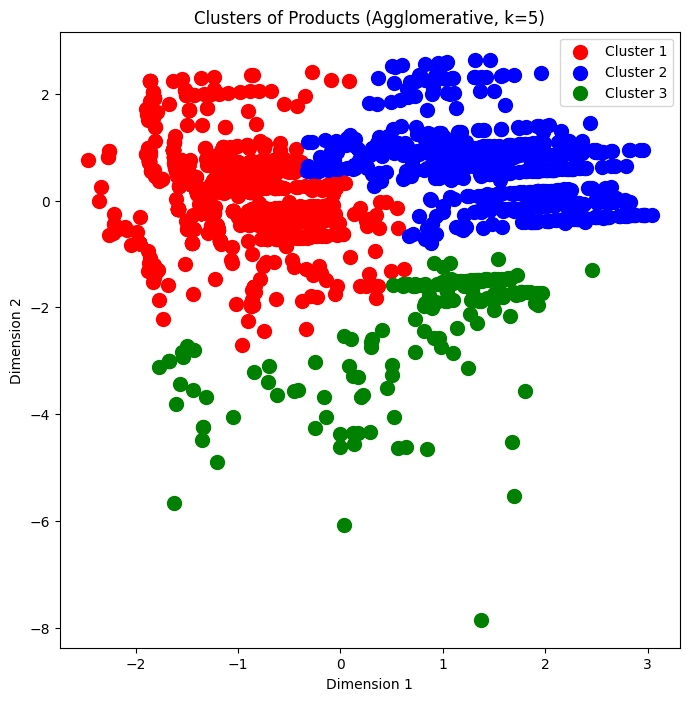

In [ ]:
### Visualizing Clusters (Agglomerative, k=3) using the same style\

from sklearn.cluster import AgglomerativeClustering

# Perform Agglomerative clustering (k=4)
agglo3 = AgglomerativeClustering(n_clusters=3, linkage="ward")
y_agglo = agglo3.fit_predict(X_reduced)

# Visualize clusters
colours = ['red', 'blue', 'green']

plt.figure(figsize=(8, 8))
for i in range(3):
    plt.scatter(X_reduced[y_agglo == i, 0], X_reduced[y_agglo == i, 1],
                s=100, c=colours[i], label='Cluster ' + str(i + 1))

plt.title('Clusters of Products (Agglomerative, k=5)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()


## Clustering Performance Evaluation and Comparison


In [27]:
# Import evaluation metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score

print("=== CLUSTERING PERFORMANCE EVALUATION ===\n")

# Calculate metrics for K-Means (k=3)
kmeans_silhouette = silhouette_score(X, y_kmeans)
kmeans_calinski = calinski_harabasz_score(X, y_kmeans)
kmeans_davies = davies_bouldin_score(X, y_kmeans)
kmeans_inertia = kmeans.inertia_

print("K-MEANS CLUSTERING (k=3):")
print(f"• Silhouette Score: {kmeans_silhouette:.4f}")
print(f"• Calinski-Harabasz Index: {kmeans_calinski:.2f}")
print(f"• Davies-Bouldin Index: {kmeans_davies:.4f}")
print(f"• Inertia (WCSS): {kmeans_inertia:.2f}")
print()

# Calculate metrics for Agglomerative Clustering (k=3)
agglo_silhouette = silhouette_score(X, y_agglo)
agglo_calinski = calinski_harabasz_score(X, y_agglo)
agglo_davies = davies_bouldin_score(X, y_agglo)

print("AGGLOMERATIVE CLUSTERING (k=3):")
print(f"• Silhouette Score: {agglo_silhouette:.4f}")
print(f"• Calinski-Harabasz Index: {agglo_calinski:.2f}")
print(f"• Davies-Bouldin Index: {agglo_davies:.4f}")
print()

# Calculate agreement between algorithms
agreement = adjusted_rand_score(y_kmeans, y_agglo)
print("ALGORITHM COMPARISON:")
print(f"• Adjusted Rand Index (Agreement): {agreement:.4f}")
print()

# Cluster size distributions
print("CLUSTER SIZE DISTRIBUTIONS:")
kmeans_counts = np.bincount(y_kmeans)
agglo_counts = np.bincount(y_agglo)

print("K-Means cluster sizes:", kmeans_counts)
print("Agglomerative cluster sizes:", agglo_counts)

=== CLUSTERING PERFORMANCE EVALUATION ===

K-MEANS CLUSTERING (k=3):
• Silhouette Score: 0.3699
• Calinski-Harabasz Index: 572.67
• Davies-Bouldin Index: 1.1401
• Inertia (WCSS): 5437.51

AGGLOMERATIVE CLUSTERING (k=3):
• Silhouette Score: 0.3522
• Calinski-Harabasz Index: 525.22
• Davies-Bouldin Index: 1.2643

ALGORITHM COMPARISON:
• Adjusted Rand Index (Agreement): 0.6779

CLUSTER SIZE DISTRIBUTIONS:
K-Means cluster sizes: [165 615 789]
Agglomerative cluster sizes: [849 547 173]


# extra stuff


# Business Benefits and Real-World Applications

###  How Clustering Benefits Supply Chain Management

**Inventory Optimization:**
- **Product Segmentation**: Different clusters represent distinct product categories with unique storage and handling requirements
- **Storage Strategy**: Products in the same cluster can be stored together, optimizing warehouse layout and reducing picking time
- **Demand Forecasting**: Cluster-based demand patterns can improve inventory planning and reduce stockouts/overstock situations

**Operational Efficiency:**
- **Warehouse Layout Optimization**: Cluster analysis can inform optimal product placement based on turnover rates and physical characteristics
- **Picking Route Optimization**: Products frequently ordered together (same cluster) can be positioned to minimize travel time
- **Resource Allocation**: Different clusters may require different handling equipment or storage conditions

**Cost Reduction:**
- **Shipping Optimization**: Products with similar weight/volume characteristics can be efficiently packed and shipped together
- **Handling Efficiency**: Grouping products with similar physical attributes reduces handling complexity
- **Space Utilization**: Optimized placement based on cluster characteristics maximizes warehouse space usage

###  Decision-Making Impact

**Strategic Decisions:**
1. **Product Portfolio Management**: Identify underperforming product clusters for discontinuation or promotion
2. **Pricing Strategy**: Products in the same cluster can have similar pricing strategies based on shared characteristics
3. **Supplier Negotiations**: Cluster insights can inform bulk purchasing decisions for similar products

**Operational Decisions:**
1. **Staff Planning**: Different clusters may require specialized handling skills or equipment
2. **Quality Control**: Products in the same cluster can share quality control processes
3. **Seasonal Planning**: Cluster-based seasonal patterns can optimize inventory levels

**Technology Investment:**
1. **Automation Priorities**: High-volume clusters may benefit most from automation investments
2. **Storage Systems**: Different clusters may require different storage technologies (temperature control, security, etc.)
3. **Information Systems**: Cluster-specific tracking and management systems

### Process Improvements

**Workflow Optimization:**
- **Standardized Processes**: Products within clusters can share standardized handling procedures
- **Cross-Training**: Staff can be trained on cluster-specific handling rather than individual products
- **Performance Monitoring**: Cluster-based KPIs provide clearer performance insights

**Customer Service Enhancement:**
- **Order Fulfillment**: Faster picking and packing through cluster-based organization
- **Product Recommendations**: Cluster insights can drive better product recommendation systems
- **Delivery Optimization**: Cluster-based shipping strategies can improve delivery times